# 1. IMPORT LIBRARIES

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import gradio as gr

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 2. LOAD DATASET

In [8]:
df = pd.read_csv(
    "network_intrusion_100000.csv"
)

print("\n========================================")
print("       NETWORK INTRUSION DETECTION")
print("========================================")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())


       NETWORK INTRUSION DETECTION

First 5 Rows:
   duration protocol  source_bytes  destination_bytes  packet_count  \
0     25.00      TCP         797.0             1293.0            74   
1     39.55      TCP         449.0             7228.0           103   
2      2.25      UDP         503.0            18397.0            74   
3     41.67      UDP         579.0             5453.0            88   
4     56.00      TCP       19404.0              715.0            77   

   failed_connections  connection_rate  source_port  destination_port   label  
0                   1            10.87        64800                20  Normal  
1                   0             3.58         9991                80  Normal  
2                   1             0.01        39274              8080  Normal  
3                   1             0.11        20793                25  Normal  
4                   3             0.43        40824                23  Normal  

Dataset Shape:
(100000, 10)

Columns:
['d

# 3. CHECK LABEL

In [9]:
if "label" not in df.columns:

    raise ValueError(
        "ERROR: 'label' column not found in dataset."
    )

# 4. MISSING VALUES

In [10]:
print("\n========================================")
print("          MISSING VALUES")
print("========================================")

print(df.isnull().sum())


          MISSING VALUES
duration              350
protocol              150
source_bytes          300
destination_bytes     300
packet_count            0
failed_connections      0
connection_rate       250
source_port             0
destination_port        0
label                 150
dtype: int64


# 5. HISTOGRAM EDA


             HISTOGRAM EDA


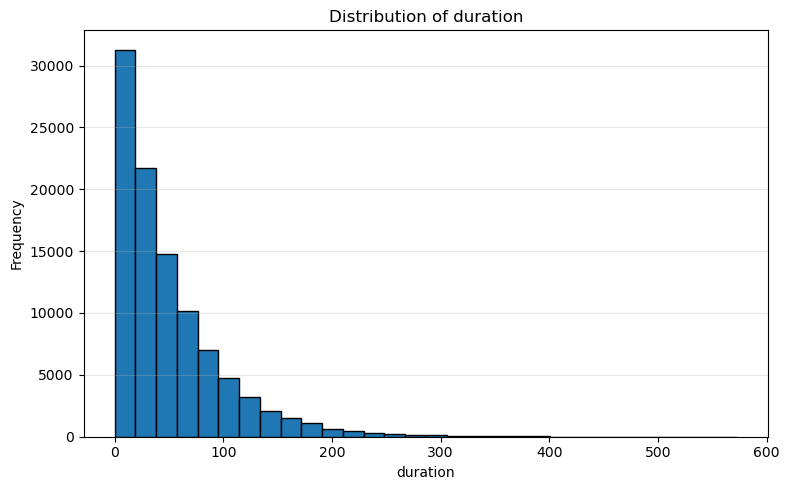

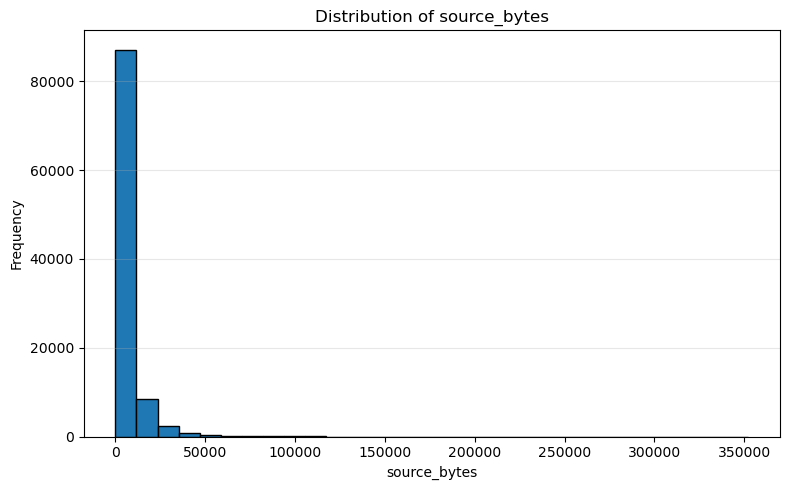

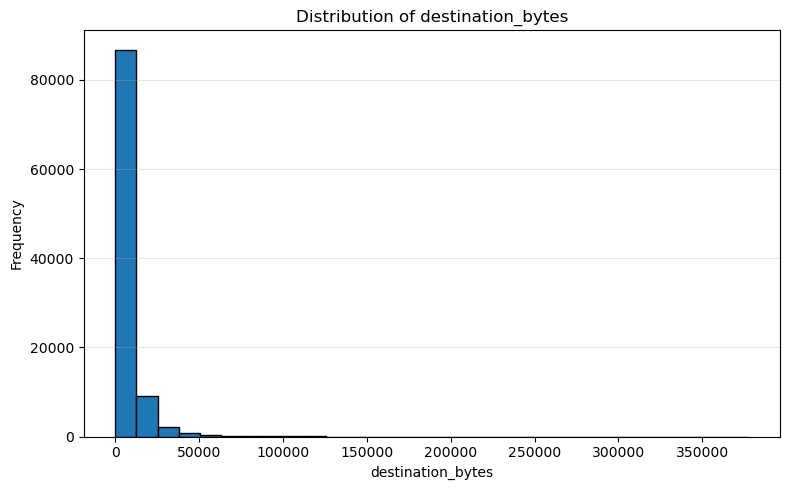

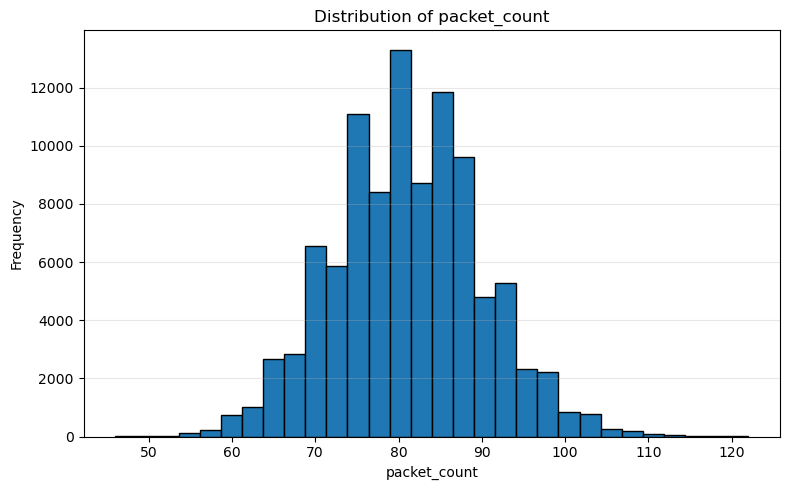

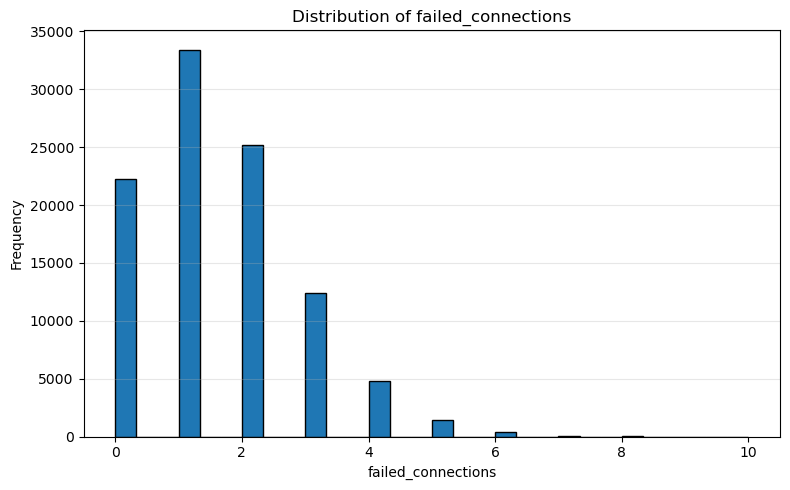

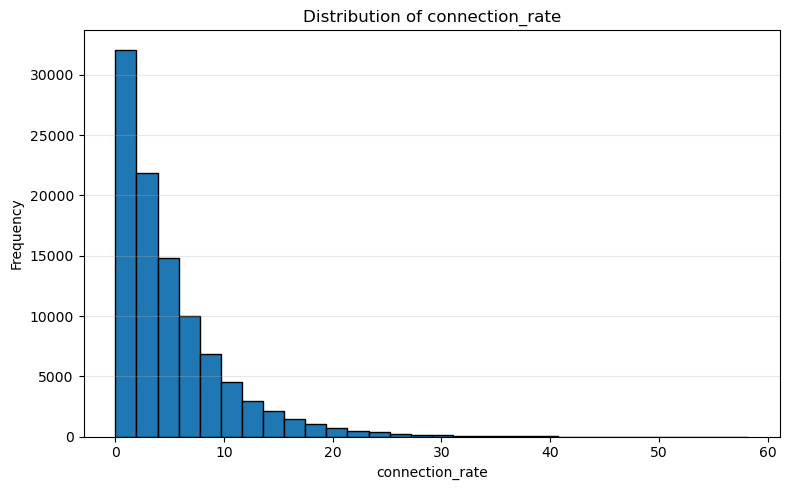

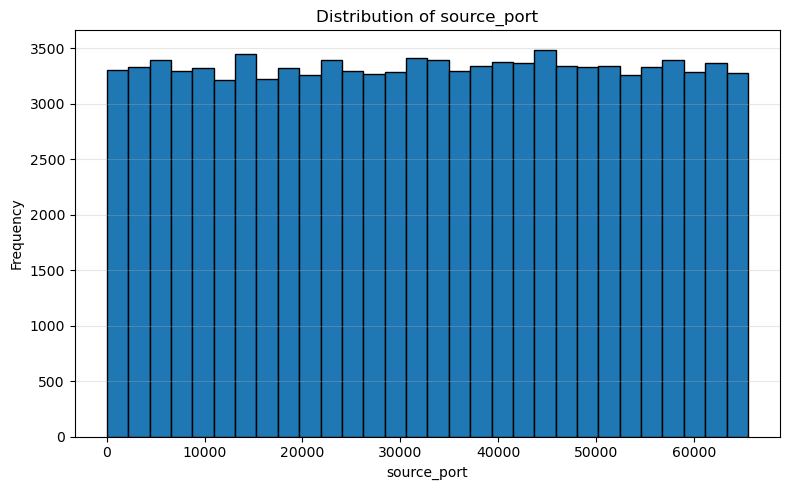

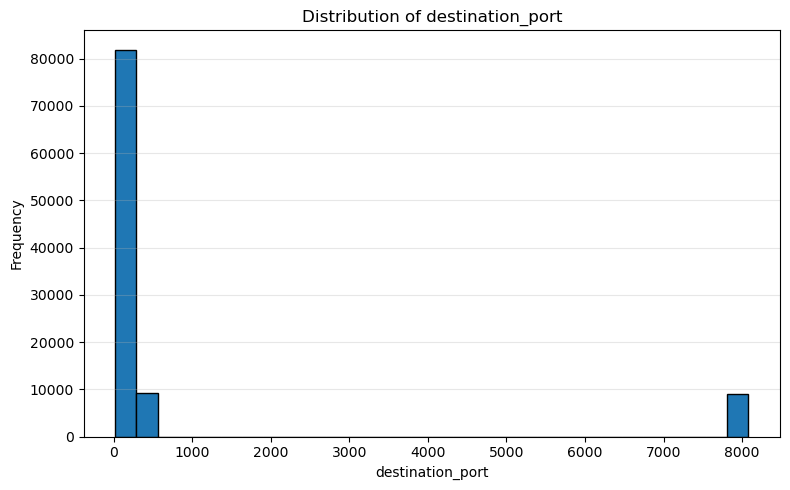

In [11]:


print("\n========================================")
print("             HISTOGRAM EDA")
print("========================================")

numerical_columns_eda = df.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns


for column in numerical_columns_eda:

    plt.figure(
        figsize=(8, 5)
    )

    plt.hist(
        df[column].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()



# 6. LABEL DISTRIBUTION

In [12]:
print("\n========================================")
print("          LABEL DISTRIBUTION")
print("========================================")

print(
    df["label"].value_counts(
        dropna=False
    )
)


          LABEL DISTRIBUTION
label
Normal       94436
Intrusion     5414
NaN            150
Name: count, dtype: int64


# 7. REMOVE DUPLICATES

In [13]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

duplicates_removed = (
    before - after
)

print(
    "\nDuplicates Removed:",
    duplicates_removed
)


Duplicates Removed: 4853


# 8. REMOVE MISSING LABELS

In [14]:

df = df.dropna(
    subset=["label"]
)

# 9. FEATURES AND TARGET

In [15]:
X = df.drop(
    "label",
    axis=1
)

y = df["label"]


print("\n========================================")
print("        FEATURES AND TARGET")
print("========================================")

print(
    "Features:",
    X.columns.tolist()
)

print(
    "\nTarget Classes:"
)

print(
    y.value_counts()
)




        FEATURES AND TARGET
Features: ['duration', 'protocol', 'source_bytes', 'destination_bytes', 'packet_count', 'failed_connections', 'connection_rate', 'source_port', 'destination_port']

Target Classes:
label
Normal       89816
Intrusion     5181
Name: count, dtype: int64


# 10. NUMERICAL FEATURES

In [17]:
numerical_features = X.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns

# 11. CATEGORICAL FEATURES

In [18]:
categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns


print(
    "\nNumerical Features:",
    list(numerical_features)
)

print(
    "Categorical Features:",
    list(categorical_features)
)


Numerical Features: ['duration', 'source_bytes', 'destination_bytes', 'packet_count', 'failed_connections', 'connection_rate', 'source_port', 'destination_port']
Categorical Features: ['protocol']


# 12. NUMERICAL PIPELINE

In [19]:
numeric_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])

# 13. CATEGORICAL PIPELINE

In [20]:
categorical_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# 14. COLUMN TRANSFORMER

In [21]:

preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_pipeline,
        numerical_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

# 15. RANDOM FOREST

In [22]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    class_weight="balanced",

    n_jobs=-1
)

# 16. COMPLETE PIPELINE

In [23]:
model = Pipeline([

    (
        "preprocessing",
        preprocessor
    ),

    (
        "classifier",
        rf
    )
])

# 17. TRAIN TEST SPLIT

In [24]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\nTraining Data:")
print(X_train.shape)

print("\nTesting Data:")
print(X_test.shape)




Training Data:
(75997, 9)

Testing Data:
(19000, 9)


# 18. TRAIN MODEL

In [25]:
print("\n========================================")
print("       TRAINING RANDOM FOREST")
print("========================================")

model.fit(
    X_train,
    y_train
)

print(
    "Training Completed Successfully!"
)




       TRAINING RANDOM FOREST
Training Completed Successfully!


# 19. PREDICTION

In [26]:

y_pred = model.predict(
    X_test
)


# 20. EVALUATION

In [27]:


accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("\n========================================")
print("          MODEL EVALUATION")
print("========================================")

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)




          MODEL EVALUATION
Accuracy  : 94.54%
Precision : 91.22%
Recall    : 94.54%
F1 Score  : 91.91%


# 21. CONFUSION MATRIX

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[    2  1034]
 [    4 17960]]



# 22. CLASSIFICATION REPORT

In [29]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

   Intrusion       0.33      0.00      0.00      1036
      Normal       0.95      1.00      0.97     17964

    accuracy                           0.95     19000
   macro avg       0.64      0.50      0.49     19000
weighted avg       0.91      0.95      0.92     19000



# 23. SAVE MODEL

In [30]:
model_file = (
    "network_intrusion_model.pkl"
)

joblib.dump(
    model,
    model_file
)

print(
    "\nModel Saved:",
    model_file
)


Model Saved: network_intrusion_model.pkl


# 24. LOAD MODEL

In [31]:
model = joblib.load(
    model_file
)

print(
    "Model Loaded Successfully!"
)

Model Loaded Successfully!


# 25. FEATURE NAMES

In [32]:
feature_names = list(
    X.columns
)


# 26. CREATE HISTOGRAM IMAGE FOR UI

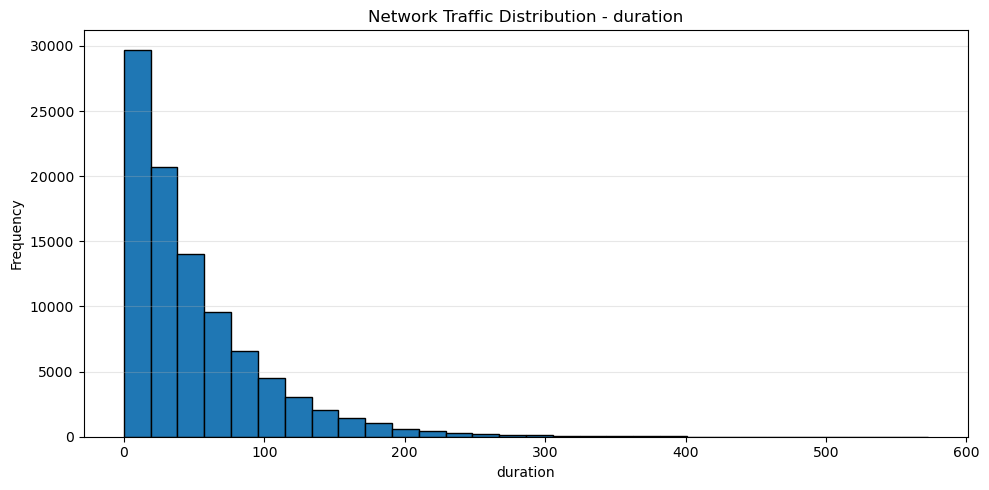

In [33]:
def create_histogram():

    if len(numerical_columns_eda) == 0:

        return None

    column = numerical_columns_eda[0]

    fig = plt.figure(
        figsize=(10, 5)
    )

    plt.hist(
        df[column].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.title(
        f"Network Traffic Distribution - {column}"
    )

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    return fig


histogram_plot = create_histogram()


# 27. GRADIO PREDICTION FUNCTION

In [34]:
def predict_intrusion(*values):

    try:

        # Create dictionary

        input_data = {}

        for column, value in zip(
            feature_names,
            values
        ):

            input_data[column] = [
                value
            ]


        # Create DataFrame

        input_df = pd.DataFrame(
            input_data
        )


        print("\nInput Received:")

        print(
            input_df
        )


        # Prediction

        prediction = model.predict(
            input_df
        )[0]


        # Probability

        confidence = None

        try:

            probabilities = (
                model.predict_proba(
                    input_df
                )
            )

            confidence = (
                probabilities.max()
                * 100
            )

        except Exception:

            confidence = None


        # Convert prediction

        prediction_text = str(
            prediction
        ).strip().lower()


        # Normal / Attack

        if prediction_text in [
            "normal",
            "benign",
            "0"
        ]:

            result = (
                "🟢 NORMAL TRAFFIC"
            )

            status = (
                "Network traffic appears normal."
            )

        else:

            result = (
                "🔴 ATTACK TRAFFIC"
            )

            status = (
                "Potential malicious traffic detected."
            )


        # Confidence

        if confidence is not None:

            confidence_text = (
                f"{confidence:.2f}%"
            )

        else:

            confidence_text = (
                "Not Available"
            )


        return (
            result,
            confidence_text,
            status
        )


    except Exception as e:

        print(
            "ERROR:",
            str(e)
        )

        return (
            "⚠️ Prediction Error",
            "N/A",
            str(e)
        )



# 28. SAMPLE DATA FUNCTION

In [35]:
def get_sample_values():

    values = []

    for column in feature_names:

        if pd.api.types.is_numeric_dtype(
            X[column]
        ):

            median_value = X[column].median()

            if pd.notna(
                median_value
            ):

                values.append(
                    float(median_value)
                )

            else:

                values.append(0)

        else:

            choices = (
                X[column]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )

            if choices:

                values.append(
                    choices[0]
                )

            else:

                values.append("")


    return values


# 29. CUSTOM CSS

In [36]:
custom_css = """

/* Main application */

.gradio-container {

    max-width: 1250px !important;

    margin: auto;

}


/* Header */

.main-header {

    text-align: center;

    padding: 25px;

    border-radius: 20px;

    margin-bottom: 20px;

    border: 1px solid #30363d;

}


.main-title {

    font-size: 38px;

    font-weight: 800;

}


.subtitle {

    font-size: 17px;

    opacity: 0.8;

}


/* Cards */

.metric-card {

    padding: 20px;

    border-radius: 16px;

    text-align: center;

    border: 1px solid #30363d;

}


.metric-title {

    font-size: 14px;

    opacity: 0.7;

}


.metric-value {

    font-size: 28px;

    font-weight: bold;

}


/* Security banner */

.security-banner {

    padding: 18px;

    border-radius: 15px;

    text-align: center;

    margin: 15px 0;

    border: 1px solid #30363d;

}


/* Result */

.result-box {

    font-size: 22px !important;

    font-weight: bold !important;

}


/* Button */

.detect-button {

    font-size: 18px !important;

    font-weight: bold !important;

}


/* Section */

.section-title {

    font-size: 22px;

    font-weight: bold;

    margin-top: 15px;

}


/* Footer */

.footer {

    text-align: center;

    padding: 20px;

    opacity: 0.7;

}

"""


# 30. GRADIO APPLICATION

In [37]:
with gr.Blocks(

    title="🛡️ Network Intrusion Detection",

    css=custom_css

) as app:
    # ========================================================
    # HEADER
    # ========================================================

    gr.HTML(
        """
        <div class="main-header">

            <div class="main-title">
                🛡️ Network Intrusion Detection System
            </div>

            <div class="subtitle">
                Machine Learning Based Cybersecurity Monitoring
            </div>

            <div class="subtitle">
                Random Forest Classifier • Real-Time Traffic Analysis
            </div>

        </div>
        """
    )


    # ========================================================
    # SECURITY STATUS
    # ========================================================

    gr.HTML(
        """
        <div class="security-banner">

            🔐 <b>SECURITY MONITORING ACTIVE</b>
            <br>
            Detecting Normal Traffic vs Potential Attack Traffic

        </div>
        """
    )


    # ========================================================
    # METRICS
    # ========================================================

    gr.Markdown(
        "## 📊 Model Performance"
    )


    with gr.Row():

        with gr.Column():

            gr.HTML(
                f"""
                <div class="metric-card">

                    <div class="metric-title">
                        Accuracy
                    </div>

                    <div class="metric-value">
                        {accuracy * 100:.2f}%
                    </div>

                </div>
                """
            )


        with gr.Column():

            gr.HTML(
                f"""
                <div class="metric-card">

                    <div class="metric-title">
                        Precision
                    </div>

                    <div class="metric-value">
                        {precision * 100:.2f}%
                    </div>

                </div>
                """
            )


        with gr.Column():

            gr.HTML(
                f"""
                <div class="metric-card">

                    <div class="metric-title">
                        Recall
                    </div>

                    <div class="metric-value">
                        {recall * 100:.2f}%
                    </div>

                </div>
                """
            )


        with gr.Column():

            gr.HTML(
                f"""
                <div class="metric-card">

                    <div class="metric-title">
                        F1 Score
                    </div>

                    <div class="metric-value">
                        {f1 * 100:.2f}%
                    </div>

                </div>
                """
            )


    # ========================================================
    # DATASET INFORMATION
    # ========================================================

    gr.Markdown(
        "## 📁 Dataset Information"
    )


    with gr.Row():

        gr.Textbox(
            value=str(len(df)),
            label="Total Records",
            interactive=False
        )

        gr.Textbox(
            value=str(len(feature_names)),
            label="Features",
            interactive=False
        )

        gr.Textbox(
            value=str(
                y.nunique()
            ),
            label="Target Classes",
            interactive=False
        )

        gr.Textbox(
            value=str(
                duplicates_removed
            ),
            label="Duplicates Removed",
            interactive=False
        )


    # ========================================================
    # TABS
    # ========================================================

    with gr.Tabs():


        # ====================================================
        # TAB 1 - INTRUSION DETECTION
        # ====================================================

        with gr.Tab(
            "🔍 Intrusion Detection"
        ):


            gr.Markdown(
                """
                ## 🌐 Network Traffic Analysis

                Enter the network traffic features below.
                The trained Random Forest model will classify
                the traffic as **Normal** or **Attack**.
                """
            )


            # -----------------------------------------------
            # INPUTS
            # -----------------------------------------------

            input_components = []


            # Divide inputs into rows

            for i in range(
                0,
                len(feature_names),
                3
            ):

                with gr.Row():

                    for column in feature_names[
                        i:i + 3
                    ]:


                        # Numeric

                        if pd.api.types.is_numeric_dtype(
                            X[column]
                        ):

                            median_value = (
                                X[column].median()
                            )


                            if pd.notna(
                                median_value
                            ):

                                default_value = float(
                                    median_value
                                )

                            else:

                                default_value = 0


                            component = gr.Number(

                                label=column,

                                value=default_value

                            )


                        # Categorical

                        else:

                            choices = (
                                X[column]
                                .dropna()
                                .astype(str)
                                .unique()
                                .tolist()
                            )


                            component = gr.Dropdown(

                                choices=choices,

                                value=(
                                    choices[0]
                                    if choices
                                    else None
                                ),

                                label=column

                            )


                        input_components.append(
                            component
                        )


            # -----------------------------------------------
            # BUTTONS
            # -----------------------------------------------

            with gr.Row():

                sample_button = gr.Button(
                    "🧪 Load Sample",
                    variant="secondary"
                )

                predict_button = gr.Button(
                    "🔍 DETECT INTRUSION",
                    variant="primary",
                    elem_classes="detect-button"
                )


            # -----------------------------------------------
            # OUTPUT
            # -----------------------------------------------

            gr.Markdown(
                "## 🚨 Detection Result"
            )


            with gr.Row():

                result = gr.Textbox(
                    label="Prediction",
                    elem_classes="result-box"
                )

                confidence = gr.Textbox(
                    label="Model Confidence"
                )


            status = gr.Textbox(
                label="Security Status",
                interactive=False
            )


            # -----------------------------------------------
            # BUTTON ACTION
            # -----------------------------------------------

            predict_button.click(

                fn=predict_intrusion,

                inputs=input_components,

                outputs=[
                    result,
                    confidence,
                    status
                ]

            )


            # -----------------------------------------------
            # SAMPLE BUTTON
            # -----------------------------------------------

            sample_button.click(

                fn=get_sample_values,

                inputs=[],

                outputs=input_components

            )


        # ====================================================
        # TAB 2 - HISTOGRAM
        # ====================================================

        with gr.Tab(
            "📈 EDA / Histogram"
        ):


            gr.Markdown(
                """
                ## 📈 Network Traffic Distribution

                Histogram visualization helps understand
                the distribution of numerical network features.
                """
            )


            gr.Plot(
                value=histogram_plot,
                label="Traffic Distribution"
            )


        # ====================================================
        # TAB 3 - MODEL INFORMATION
        # ====================================================

        with gr.Tab(
            "🤖 Model Information"
        ):


            gr.Markdown(
                """
                ## 🤖 Random Forest Classifier

                **Algorithm:** Random Forest

                **Number of Trees:** 100

                **Class Weight:** Balanced

                **Train/Test Split:** 80% / 20%

                **Random State:** 42

                **Preprocessing:**

                - Missing numerical values → Median
                - Numerical scaling → StandardScaler
                - Missing categorical values → Most Frequent
                - Categorical encoding → OneHotEncoder

                **Target:**

                🟢 Normal Traffic

                🔴 Attack Traffic
                """
            )


            gr.Markdown(
                "### 📋 Input Features"
            )


            gr.JSON(
                value=feature_names,
                label="Feature Names"
            )


        # ====================================================
        # TAB 4 - CONFUSION MATRIX
        # ====================================================

        with gr.Tab(
            "📊 Confusion Matrix"
        ):


            gr.Markdown(
                """
                ## 📊 Confusion Matrix

                The confusion matrix shows how accurately
                the model classified the test samples.
                """
            )


            gr.Dataframe(
                value=pd.DataFrame(
                    cm
                ),
                headers=[
                    f"Class {i}"
                    for i in range(
                        len(cm)
                    )
                ],
                label="Confusion Matrix"
            )


    # ========================================================
    # FOOTER
    # ========================================================

    gr.HTML(
        """
        <div class="footer">

            🛡️ Network Intrusion Detection System

            <br>

            Powered by Python • Scikit-learn • Random Forest • Gradio

            <br>

            Machine Learning Cybersecurity Project

        </div>
        """
    )


C:\Users\ACER\AppData\Local\Temp\ipykernel_10020\4031091340.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(


# 31. LAUNCH

In [38]:
print("\n========================================")
print("       STARTING GRADIO APPLICATION")
print("========================================")

app.launch()


       STARTING GRADIO APPLICATION
* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.
